# Financial Analysis of Microsoft, Tesla, and Apple

This project analyzes financial data from the 10-K filings of Microsoft, Tesla, and Apple obtained from the SEC EDGAR database.

## Objective
The objective of this analysis is to evaluate:
- Growth trends
- Profitability
- Financial stability

using key financial metrics such as revenue, net income, assets, liabilities, and operating cash flow.

## Methodology

This analysis follows a structured approach:

1. Financial data was extracted from 10-K filings of Microsoft, Tesla, and Apple.
2. Key metrics were selected: Revenue, Net Income, Total Assets, Total Liabilities, and Operating Cash Flow.
3. The dataset was organized into a CSV file.
4. Data was loaded into Google Colab using pandas.
5. Data cleaning and sorting were performed.
6. Year-over-Year (YoY) analysis was conducted.
7. Aggregated and visual analysis was performed.

This ensures consistency and comparability across companies.

In [28]:
from google.colab import files
uploaded = files.upload()

Saving financial_dataset.csv to financial_dataset (3).csv


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("financial_dataset.csv")
df.head()

,Company,Year,Revenue (USD Billions),Net Income (USD Billions),Total Assets (USD Billions),Total Liabilities (USD Billions),Operating Cash Flow (USD Billions)
0,Microsoft,2025,245,88,512,243,118
1,Microsoft,2024,211,72,411,205,87
2,Microsoft,2023,198,72,364,198,89
3,Tesla,2024,97,15,106,43,13
4,Tesla,2023,96,15,106,43,13


In [31]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Company                             9 non-null      object
 1   Year                                9 non-null      int64 
 2   Revenue (USD Billions)              9 non-null      int64 
 3   Net Income (USD Billions)           9 non-null      int64 
 4   Total Assets (USD Billions)         9 non-null      int64 
 5   Total Liabilities (USD Billions)    9 non-null      int64 
 6   Operating Cash Flow (USD Billions)  9 non-null      int64 
dtypes: int64(6), object(1)
memory usage: 636.0+ bytes


,0
Company,0
Year,0
Revenue (USD Billions),0
Net Income (USD Billions),0
Total Assets (USD Billions),0
Total Liabilities (USD Billions),0
Operating Cash Flow (USD Billions),0


## Data Exploration

- The dataset contains financial data for three companies across multiple years.
- No missing values were found, indicating clean data.
- All values are measured in USD billions for consistency.
- The dataset is suitable for time-series and comparative analysis.

In [32]:
df = df.sort_values(["Company", "Year"])

In [33]:
df["Revenue YoY %"] = df.groupby("Company")["Revenue (USD Billions)"].pct_change() * 100
df["Net Income YoY %"] = df.groupby("Company")["Net Income (USD Billions)"].pct_change() * 100
df["Assets YoY %"] = df.groupby("Company")["Total Assets (USD Billions)"].pct_change() * 100
df["Liabilities YoY %"] = df.groupby("Company")["Total Liabilities (USD Billions)"].pct_change() * 100
df["Cash Flow YoY %"] = df.groupby("Company")["Operating Cash Flow (USD Billions)"].pct_change() * 100

df

,Company,Year,Revenue (USD Billions),Net Income (USD Billions),Total Assets (USD Billions),Total Liabilities (USD Billions),Operating Cash Flow (USD Billions),Revenue YoY %,Net Income YoY %,Assets YoY %,Liabilities YoY %,Cash Flow YoY %
8,Apple,2022,394,99,352,302,122,NaN,NaN,NaN,NaN,NaN
7,Apple,2023,383,97,352,290,110,-2.791878,-2.020202,0.000000,-3.973510,-9.836066
6,Apple,2024,383,97,352,290,110,0.000000,0.000000,0.000000,0.000000,0.000000
2,Microsoft,2023,198,72,364,198,89,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,211,72,411,205,87,6.565657,0.000000,12.912088,3.535354,-2.247191
0,Microsoft,2025,245,88,512,243,118,16.113744,22.222222,24.574209,18.536585,35.632184
5,Tesla,2022,81,12,82,36,14,NaN,NaN,NaN,NaN,NaN
4,Tesla,2023,96,15,106,43,13,18.518519,25.000000,29.268293,19.444444,-7.142857
3,Tesla,2024,97,15,106,43,13,1.041667,0.000000,0.000000,0.000000,0.000000


## Year-over-Year (YoY) Analysis

Year-over-Year analysis helps measure growth trends.

Observations:

- Microsoft shows consistent growth in revenue and cash flow.
- Apple maintains stable performance with minimal fluctuations.
- Tesla shows growth but with higher variability.

This indicates Microsoft is expanding steadily, Apple is stable, and Tesla is evolving.

In [34]:
df.groupby("Company").mean(numeric_only=True)

,Year,Revenue (USD Billions),Net Income (USD Billions),Total Assets (USD Billions),Total Liabilities (USD Billions),Operating Cash Flow (USD Billions),Revenue YoY %,Net Income YoY %,Assets YoY %,Liabilities YoY %,Cash Flow YoY %
Company,,,,,,,,,,,
Apple,2023.0,386.666667,97.666667,352.0,294.000000,114.000000,-1.395939,-1.010101,0.000000,-1.986755,-4.918033
Microsoft,2024.0,218.000000,77.333333,429.0,215.333333,98.000000,11.339700,11.111111,18.743149,11.035969,16.692496
Tesla,2023.0,91.333333,14.000000,98.0,40.666667,13.333333,9.780093,12.500000,14.634146,9.722222,-3.571429


## Aggregated Analysis

- Apple has the highest average net income, showing strong profitability.
- Microsoft performs strongly across all metrics.
- Tesla has lower averages but shows growth potential.

This comparison highlights differences in financial strength.

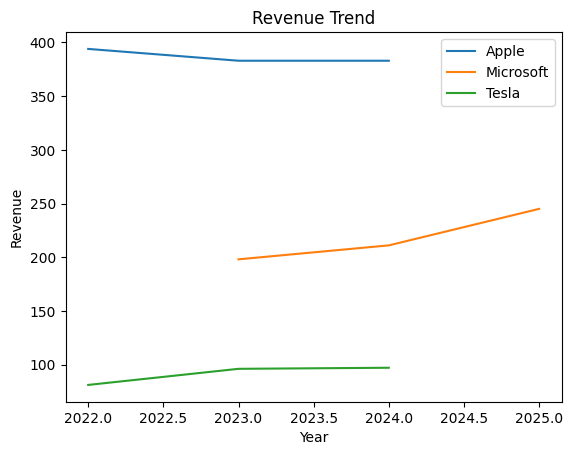

In [35]:
for company in df["Company"].unique():
    subset = df[df["Company"] == company]
    plt.plot(subset["Year"], subset["Revenue (USD Billions)"], label=company)

plt.legend()
plt.title("Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

## Visualization Insights

- Microsoft shows a strong upward revenue trend.
- Apple maintains high but stable revenue.
- Tesla shows increasing but less consistent growth.

Graphs help visually compare performance across companies.

## Conclusion

This analysis highlights key financial trends:

- Microsoft is the strongest growth company with consistent increases across all metrics.
- Apple is the most stable and profitable company.
- Tesla shows promising growth but higher volatility.

Overall:
- Microsoft leads in expansion
- Apple leads in stability and profitability
- Tesla represents a high-growth but less stable company

This demonstrates how financial data can be used to evaluate company performance and support decision-making.

## 🤖 AI Financial Chatbot

This section implements a simple rule-based chatbot that answers predefined financial queries using the analyzed dataset.

In [36]:
def simple_chatbot(user_query):
    user_query = user_query.lower()

    if "revenue" in user_query and "microsoft" in user_query:
        value = df[df["Company"] == "Microsoft"]["Revenue (USD Billions)"].values[-1]
        return f"Microsoft's latest revenue is {value} billion USD."

    elif "net income" in user_query and "apple" in user_query:
        value = df[df["Company"] == "Apple"]["Net Income (USD Billions)"].values[-1]
        return f"Apple's net income is {value} billion USD."

    elif "assets" in user_query and "tesla" in user_query:
        value = df[df["Company"] == "Tesla"]["Total Assets (USD Billions)"].values[-1]
        return f"Tesla's total assets are {value} billion USD."

    elif "cash flow" in user_query and "microsoft" in user_query:
        value = df[df["Company"] == "Microsoft"]["Operating Cash Flow (USD Billions)"].values[-1]
        return f"Microsoft's cash flow is {value} billion USD."

    elif "change" in user_query and "apple" in user_query:
        apple = df[df["Company"] == "Apple"].sort_values("Year")
        change = apple["Net Income (USD Billions)"].diff().iloc[-1]
        return f"Apple's net income changed by {change} billion USD last year."

    elif "liabilities" in user_query and "microsoft" in user_query:
        value = df[df["Company"] == "Microsoft"]["Total Liabilities (USD Billions)"].values[-1]
        return f"Microsoft's liabilities are {value} billion USD."

    elif "highest revenue" in user_query:
        top = df.sort_values("Revenue (USD Billions)", ascending=False).iloc[0]
        return f"{top['Company']} has the highest revenue: {top['Revenue (USD Billions)']} billion USD."

    else:
        return "Sorry, I can only answer predefined financial questions."


In [37]:
print(simple_chatbot("Microsoft revenue"))
print(simple_chatbot("Apple net income"))
print(simple_chatbot("Tesla assets"))
print(simple_chatbot("highest revenue"))
print(simple_chatbot("Microsoft cash flow"))
print(simple_chatbot("Apple income change"))
print(simple_chatbot("highest revenue"))

Microsoft's latest revenue is 245 billion USD.
Apple's net income is 97 billion USD.
Tesla's total assets are 106 billion USD.
Apple has the highest revenue: 394 billion USD.
Microsoft's cash flow is 118 billion USD.
Apple's net income changed by 0.0 billion USD last year.
Apple has the highest revenue: 394 billion USD.




### How it Works:
The chatbot uses rule-based logic (if-else) to match user queries and return financial data.

### Supported Queries:
- Microsoft revenue
- Apple net income
- Tesla assets
- Microsoft cash flow
- Apple income change
- Microsoft liabilities
- Highest revenue company

### Limitations:
- Only predefined queries supported
- No NLP or AI model used
- Limited understanding of user input

### Conclusion:
This project demonstrates a basic AI chatbot prototype for financial analysis.